
# Unit 2 — Advanced Visualization & Storytelling (UE24CS342AA9)
## Activity Notebook: Build an Interactive Retail Sales Dashboard

### Scenario

You have just joined the analytics team of **UrbanCart**, a mid-sized retail chain with stores across
three regions. Regional managers currently receive a static monthly PDF report and complain that:

1. They can't drill into *why* a number moved without emailing the analytics team.
2. Comparing stores or products side by side means flipping between many separate PDF pages.
3. Spotting a sudden dip in a specific product/store is slow and easy to miss.

**Your job:** apply the interaction techniques from the lecture — dynamic queries, coordinated views
& brushing, table lens, focus+context drill-down, and single-screen dashboard design — to build an
**interactive exploration tool** that solves these three complaints.

### How this notebook is organized

- A sample dataset is generated for you (Task 0) — don't skip running it.
- Each task states the **real-world usage**: which complaint above it solves, and why the technique
  fits.
- Tasks give you a **scaffold** (imports, helper stubs, expected output) — **you write the core logic**
  marked with `# TODO`. Do not just copy the Demo notebook's code verbatim — the data shape, column
  names and the exact question being asked are different here, so you will need to adapt the pattern,
  not paste it.


> **Grading-relevant tip:** every `# TODO` cell tells you what the final variable/plot must be named
> or show — read it before coding, since later cells depend on it.



## Task 0 — Load the Sample Dataset (provided)

Run the cells below as-is. This generates `sales_df`: 24 months of daily-aggregated sales across
6 stores (3 regions), 10 products (4 categories), including revenue, profit and customer ratings —
enough structure to support every technique you'll build below.


In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

import ipywidgets as widgets
from ipywidgets import interact, HBox, VBox

sns.set_theme(style="whitegrid")
np.random.seed(7)
print("Libraries loaded.")


Libraries loaded.


In [ ]:

# --- Sample dataset generator: UrbanCart retail sales (provided, do not need to modify) ---
stores = pd.DataFrame({
    "store_id":   ["S01", "S02", "S03", "S04", "S05", "S06"],
    "store_city": ["Bengaluru", "Mysuru", "Mumbai", "Pune", "Delhi", "Jaipur"],
    "region":     ["South", "South", "West", "West", "North", "North"],
})

products = pd.DataFrame({
    "product":  ["Wireless Earbuds", "Smartwatch", "Laptop Sleeve", "USB-C Hub",
                 "Yoga Mat", "Dumbbell Set", "Running Shoes", "Track Jacket",
                 "Air Fryer", "Blender"],
    "category": ["Electronics", "Electronics", "Electronics", "Electronics",
                 "Fitness", "Fitness", "Apparel", "Apparel",
                 "Home", "Home"],
    "unit_price": [1499, 4999, 899, 1299, 799, 2499, 3499, 1999, 3999, 2299],
})

months = pd.date_range("2023-01-01", periods=24, freq="MS")

rows = []
for _, s in stores.iterrows():
    store_scale = np.random.uniform(0.7, 1.4)          # some stores just sell more
    for _, p in products.iterrows():
        product_scale = np.random.uniform(0.6, 1.6)
        trend = np.random.normal(0.01, 0.01)             # slow month-over-month growth/decline
        for i, m in enumerate(months):
            seasonal = 1 + 0.25 * np.sin(2 * np.pi * (m.month / 12))   # yearly seasonality
            units = max(0, np.random.poisson(15 * store_scale * product_scale * seasonal * (1 + trend) ** i))
            revenue = units * p["unit_price"]
            profit_margin = np.random.uniform(0.12, 0.35)
            profit = revenue * profit_margin
            rating = np.clip(np.random.normal(4.1, 0.4), 1, 5)
            # NOTE: use bracket indexing (p["product"]), not p.product -- pandas Series already has
            # a built-in .product() method, so attribute access on a column literally named "product"
            # silently returns that method instead of your data. This is a common real-world gotcha.
            rows.append((m, s["store_id"], s["store_city"], s["region"], p["product"], p["category"],
                         p["unit_price"], units, revenue, profit, round(rating, 1)))

sales_df = pd.DataFrame(rows, columns=[
    "month", "store_id", "store_city", "region", "product", "category",
    "unit_price", "units_sold", "revenue", "profit", "avg_rating"
])
for _col in ["units_sold", "revenue", "profit"]:
    sales_df[_col] = sales_df[_col].astype(float)  # float, so the anomaly injection below can scale them

# Inject one deliberate "anomaly" for Task 4 (a real dip a manager would want to investigate)
mask = (sales_df.store_id == "S03") & (sales_df["product"] == "Smartwatch") & (sales_df.month == "2024-06-01")
sales_df.loc[mask, ["units_sold", "revenue", "profit"]] = sales_df.loc[mask, ["units_sold", "revenue", "profit"]] * 0.15

print(sales_df.shape)
sales_df.head()


(1440, 11)


,month,store_id,store_city,region,product,category,unit_price,units_sold,revenue,profit,avg_rating
0,2023-01-01,S01,Bengaluru,South,Wireless Earbuds,Electronics,1499,17.0,25483.0,4631.305022,3.9
1,2023-02-01,S01,Bengaluru,South,Wireless Earbuds,Electronics,1499,19.0,28481.0,8682.717042,3.8
2,2023-03-01,S01,Bengaluru,South,Wireless Earbuds,Electronics,1499,16.0,23984.0,8014.910391,4.0
3,2023-04-01,S01,Bengaluru,South,Wireless Earbuds,Electronics,1499,31.0,46469.0,11438.468953,4.8
4,2023-05-01,S01,Bengaluru,South,Wireless Earbuds,Electronics,1499,22.0,32978.0,5511.128059,4.2



**Reflection (answer in a sentence or two, in this markdown cell):**
Before writing any code, look at the columns above. Which columns would you use as *filters* for
dynamic querying, and which would you use to *link* views together for brushing? Write your answer
here.

_Your answer:_



## Task 1 — Static vs. Interactive: Which Report Actually Answers the Manager's Question?

**Real-world usage:** Complaint #1 ("flipping through PDF pages"). A regional manager asks:
*"Show me total revenue by product, and let me check exactly how much any bar is worth without
squinting at a printed axis."*

**Why this technique:** A static bar chart is fine for the *headline* number, but it can't answer a
precise follow-up question live — that needs a hover-enabled interactive chart (Slide 4-8).

### Your task
1. Build a **static** `matplotlib`/`seaborn` bar chart of total revenue per `product`, sorted
   descending.
2. Build the **same** chart as an **interactive** `plotly` bar chart where hovering shows the exact
   revenue figure and the category of that product.
3. In the markdown cell below, state in 1-2 sentences: for *this specific* manager request, which
   version wins, and why (tie your answer to target-audience / data-story / ROI from the slide).


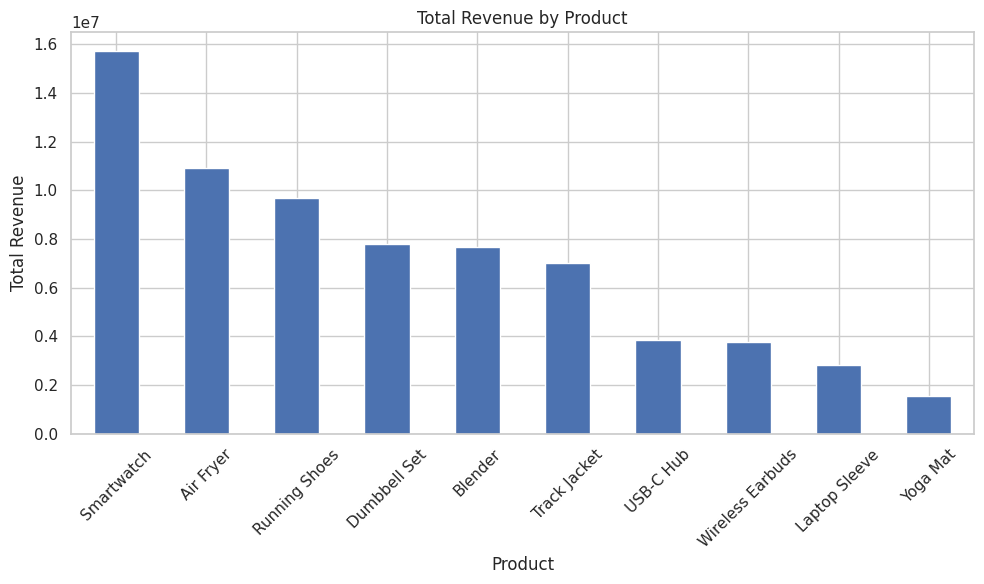

In [ ]:
# --- 1a. STATIC chart ---

# Group revenue by product and sort in descending order
revenue_by_product = (
    sales_df.groupby("product")["revenue"]
    .sum()
    .sort_values(ascending=False)
)

# Plot
plt.figure(figsize=(10, 6))
revenue_by_product.plot(kind="bar")

plt.title("Total Revenue by Product")
plt.xlabel("Product")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# --- 1b. INTERACTIVE chart ---

import plotly.express as px

# Group by both product and category
revenue_by_product_category = (
    sales_df.groupby(["product", "category"], as_index=False)["revenue"]
    .sum()
    .sort_values("revenue", ascending=False)
)

# Interactive bar chart
fig = px.bar(
    revenue_by_product_category,
    x="product",
    y="revenue",
    hover_data=["category"],
    title="Total Revenue by Product"
)

fig.show()


**Your 1-2 sentence answer:**

_Type here._ The interactive chart groups revenue by product and category, then uses Plotly Express to create a bar chart with category shown on hover. This makes the chart more informative and interactive than the static version.



## Task 2 — Dynamic Queries: Let Managers Filter Without Asking You

**Real-world usage:** Regional managers want to self-serve answer questions like *"which
products, in what price range, sold above X units last month?"* without emailing the analytics team
every time (Complaint #1 again, but for filtering rather than just reading).

**Why this technique:** Dynamic queries (double-ended range sliders) let the pattern emerge from the
noise live, with the response updating in real time (Slide 23).

### Your task
Build **two** linked `ipywidgets` range sliders:
- `price_slider` — filters on `unit_price`
- `units_slider` — filters on `units_sold`

Write a function `dynamic_filter(price_range, units_range)` that:
1. Filters `sales_df` to rows where `unit_price` is inside `price_range` **and** `units_sold` is
   inside `units_range`.
2. Prints how many rows match out of the total.
3. Shows a scatter plot of `unit_price` vs `units_sold`, with matching rows highlighted in a
   distinct color against all other rows in gray (same pattern as the Demo notebook's dynamic query
   cell — but you must build the filter condition and the plot yourself for these two columns).

Wire it up with `interact()`.


In [ ]:
from ipywidgets import FloatRangeSlider, IntRangeSlider, interact
import matplotlib.pyplot as plt

# Price slider: min to max unit price
price_slider = FloatRangeSlider(
    value=[sales_df.unit_price.min(), sales_df.unit_price.max()],
    min=sales_df.unit_price.min(),
    max=sales_df.unit_price.max(),
    step=1,
    description="Price:"
)

# Units sold slider: min to max units sold
units_slider = IntRangeSlider(
    value=[sales_df.units_sold.min(), sales_df.units_sold.max()],
    min=sales_df.units_sold.min(),
    max=sales_df.units_sold.max(),
    step=1,
    description="Units:"
)

def dynamic_filter(price_range, units_range):

    # Filter using BOTH ranges
    filtered = sales_df[
        (sales_df["unit_price"].between(price_range[0], price_range[1])) &
        (sales_df["units_sold"].between(units_range[0], units_range[1]))
    ]

    # Print matching rows
    print(f"{len(filtered)} / {len(sales_df)} rows match")

    # Plot all rows
    plt.figure(figsize=(10, 6))
    plt.scatter(
        sales_df["unit_price"],
        sales_df["units_sold"],
        color="gray",
        alpha=0.4,
        label="All rows"
    )

    # Highlight filtered rows
    plt.scatter(
        filtered["unit_price"],
        filtered["units_sold"],
        alpha=0.8,
        label="Filtered rows"
    )

    plt.xlabel("Unit Price")
    plt.ylabel("Units Sold")
    plt.title("Dynamic Sales Filter")
    plt.legend()
    plt.show()

# Connect sliders to function
interact(
    dynamic_filter,
    price_range=price_slider,
    units_range=units_slider
)

interactive(children=(FloatRangeSlider(value=(799.0, 4999.0), description='Price:', max=4999.0, min=799.0, ste…

<function __main__.dynamic_filter(price_range, units_range)>


**Reflection:** The slide notes dynamic queries work well "up to ~100,000 points with five or fewer
sliders." `sales_df` has far fewer rows. If UrbanCart grew to 500 stores and this dataset became 50x
larger, would two sliders still be enough, or would you need a different technique from the lecture?
Name one.

_Your answer:_ Two sliders would still be enough for the filter conditions, but with 50× more data, dynamic plotting may become slow. One better technique is sampling, where only a representative subset of points is plotted to keep the visualization responsive.



## Task 3 — Coordinated Views & Cross-View Brushing: Compare Stores Without Flipping Pages

**Real-world usage:** Complaint #2 — "comparing stores means flipping between many PDF pages."
A manager wants to click one store in an overview chart and instantly see that store's category
breakdown and its monthly trend, without losing sight of how it compares to the others.

**Why this technique:** Coordinated multiple views + brushing (Slide 24) — selecting a subset in one
view highlights the same records everywhere else, replacing the working-memory cost of flipping pages.

### Your task
Build **three linked views** for a store the user selects from a dropdown:
1. **Overview bar chart** — total revenue per store (all 6 stores), with the selected store's bar in
   a distinct color and every other store's bar in gray (this is the "muted unselected categories"
   trick from the slide).
2. **Category breakdown** — a pie or bar chart of revenue by `category`, filtered to the selected
   store only.
3. **Monthly trend line** — revenue by `month`, filtered to the selected store only.

Wrap all three in one function driven by a single `ipywidgets.Dropdown` of `store_id` values, and lay
the three charts out together (e.g. with `plt.subplots` for 1+2+3, or separate `display()` calls).


In [ ]:
import matplotlib.pyplot as plt
from ipywidgets import Dropdown, interact

store_overview = sales_df.groupby("store_id").revenue.sum().reset_index()

def store_coordinated_view(selected_store):

    # Filter selected store
    selected_data = sales_df[sales_df["store_id"] == selected_store]

    # Create 3 charts
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # --- 1. Store revenue overview ---
    bars = axes[0].bar(
        store_overview["store_id"],
        store_overview["revenue"],
        color="lightgray"
    )

    # Highlight selected store
    for bar, store in zip(bars, store_overview["store_id"]):
        if store == selected_store:
            bar.set_color("steelblue")

    axes[0].set_title("Revenue by Store")
    axes[0].set_xlabel("Store")
    axes[0].set_ylabel("Revenue")
    axes[0].tick_params(axis="x", rotation=45)

    # --- 2. Category breakdown ---
    category_revenue = (
        selected_data.groupby("category")["revenue"]
        .sum()
    )

    axes[1].bar(
        category_revenue.index,
        category_revenue.values
    )

    axes[1].set_title(f"Category Revenue - {selected_store}")
    axes[1].set_xlabel("Category")
    axes[1].set_ylabel("Revenue")
    axes[1].tick_params(axis="x", rotation=45)

    # --- 3. Monthly revenue trend ---
    monthly_revenue = (
        selected_data.groupby("month")["revenue"]
        .sum()
    )

    axes[2].plot(
        monthly_revenue.index,
        monthly_revenue.values,
        marker="o"
    )

    axes[2].set_title(f"Monthly Revenue - {selected_store}")
    axes[2].set_xlabel("Month")
    axes[2].set_ylabel("Revenue")
    axes[2].tick_params(axis="x", rotation=45)

    plt.tight_layout()
    plt.show()


# Dropdown of stores
store_dropdown = Dropdown(
    options=stores["store_id"].unique(),
    description="Store:"
)

# Connect dropdown to function
interact(
    store_coordinated_view,
    selected_store=store_dropdown
)

interactive(children=(Dropdown(description='Store:', options=('S01', 'S02', 'S03', 'S04', 'S05', 'S06'), value…

<function __main__.store_coordinated_view(selected_store)>


**Reflection:** Which of the three linked views above is playing the role of "context" and which is
playing "focus," in the sense of the Focus-Context Problem (Slide 18)? Is that the same distinction as
brushing, or a different but related idea? Explain briefly.

_Your answer:_ The store revenue overview provides the context, while the category breakdown and monthly revenue trend provide the focus for the selected store. This is related to brushing, but not exactly the same: brushing means interactively selecting data points to highlight them, whereas Focus-Context means showing a detailed focus while keeping the surrounding data as context.



## Task 4 — Focus + Context Drill-Down: Investigate the Dip

**Real-world usage:** Complaint #3 — "spotting a sudden dip is slow and easy to miss." One product at
one store has a real anomaly hidden in `sales_df` (planted in Task 0). A manager needs to find it and
drill in **without losing the overview**, using the *cheapest* interaction tier that still answers the
question (Drill-Down Cost Hierarchy, Slide 17).

### Your task
**Part A — find the anomaly.**
Write code that computes, for every `(store_id, product)` pair, the ratio of the *minimum* month's
`units_sold` to the *median* month's `units_sold` across the 24 months. Sort ascending and show the
top 5 most extreme drops. (Hint: `groupby(["store_id","product"]).units_sold.agg(...)` with a custom
function, or compute `min` and `median` separately and combine.)

**Part B — build the drill-down.**
Using **hover** (cheap tier) on an overview chart of all `(store_id, product)` trend lines, let the
user identify the anomalous line. Then, given the `store_id`/`product` you found in Part A, plot its
monthly trend **alongside** a faint gray context line showing the *average* trend across all
stores/products for the same product — so the dip is visible with its context still present (not a
full window replacement).


In [ ]:
# --- Part A: find the anomaly ---

anomaly_ranking = (
    sales_df.groupby(["store_id", "product"])["revenue"]
    .agg(["min", "median"])
    .assign(min_median_ratio=lambda x: x["min"] / x["median"])
    .sort_values("min_median_ratio", ascending=True)
    .head(5)
)

anomaly_ranking

,,min,median,min_median_ratio
store_id,product,,,
S03,Smartwatch,19496.1,104979.0,0.185714
S05,USB-C Hub,2598.0,10392.0,0.250000
S01,Track Jacket,5997.0,19990.0,0.300000
S03,USB-C Hub,6495.0,21433.5,0.303030
S02,Yoga Mat,2397.0,7590.5,0.315789


In [ ]:
import plotly.express as px
import pandas as pd

# --- Part B: drill-down with context preserved ---

# TODO 1: Overview line chart
overview = (
    sales_df.groupby(["month", "store_id", "product"], as_index=False)["units_sold"]
    .sum()
)

fig = px.line(
    overview,
    x="month",
    y="units_sold",
    color="store_id",
    line_dash="product",
    hover_data=["store_id", "product"],
    title="Monthly Units Sold by Store and Product"
)

fig.show()


# TODO 2: Focus + context for top anomaly

# Get the top anomaly identified in Part A
top_anomaly = anomaly_ranking.index[0]
anomaly_store = top_anomaly[0]
anomaly_product = top_anomaly[1]

# Focus: monthly units sold for the anomalous store-product pair
focus = (
    sales_df[
        (sales_df["store_id"] == anomaly_store) &
        (sales_df["product"] == anomaly_product)
    ]
    .groupby("month", as_index=False)["units_sold"]
    .sum()
)

# Context: average monthly units sold for the SAME product
# across all OTHER stores
context = (
    sales_df[
        (sales_df["product"] == anomaly_product) &
        (sales_df["store_id"] != anomaly_store)
    ]
    .groupby(["month", "store_id"], as_index=False)["units_sold"]
    .sum()
    .groupby("month", as_index=False)["units_sold"]
    .mean()
)

# Rename columns
focus = focus.rename(columns={"units_sold": "Focus"})
context = context.rename(columns={"units_sold": "Context"})

# Combine focus + context
comparison = pd.merge(
    focus,
    context,
    on="month",
    how="outer"
).sort_values("month")

# Plot both on one chart
fig = px.line(
    comparison,
    x="month",
    y=["Focus", "Context"],
    markers=True,
    title=f"Focus vs Context: {anomaly_store} - {anomaly_product}"
)

fig.show()


**Reflection:** Which interaction-cost tier (eye fixation / hover / click-to-open panel / window
replacement) did you use to first *spot* the anomaly, and which did you use to *investigate* it? Was
using two different tiers the right call, per the lecture's design rule?

_Your answer:_I used hover to first spot the anomaly because it is a low-cost interaction, and then used a window replacement/drill-down view to investigate it in detail. Yes, using two different tiers was the right call because the lecture’s design rule is to use cheap interactions for discovery and higher-cost interactions only when deeper investigation is needed.



## Task 5 — Table Lens: A Scannable Product Performance Table

**Real-world usage:** A manager wants a single table listing every product's total revenue, total
profit, and average rating across all stores — but a plain spreadsheet of 10 rows x many numeric
columns is still hard to compare at a glance across all three metrics simultaneously.

**Why this technique:** Table Lens (Slide 27) maps numeric columns to in-cell bars, so magnitude
differences are visible pre-attentively while the table stays sortable/readable as text.

### Your task
1. Build a summary DataFrame: one row per `product`, columns for total `revenue`, total `profit`, and
   mean `avg_rating`.
2. Sort it by total revenue, descending.
3. Style it as a Table Lens using `.style.bar(...)` — a different bar color per numeric column, as in
   the Demo notebook — and add a meaningful `.set_caption(...)`.
4. Below the table, add **one more cell**: sort the *same* summary table by `profit` instead of
   `revenue`, and re-render the styled table. Do the top rows change order? Note what that tells a
   manager about revenue vs. profitability.


In [ ]:
# --- Task 5: Table Lens ---

product_summary = (
    sales_df.groupby("product", as_index=False)
    .agg(
        revenue=("revenue", "sum"),
        profit=("profit", "sum"),
        avg_rating=("avg_rating", "mean")
    )
    .sort_values("revenue", ascending=False)
)

product_summary.style \
    .bar(subset=["revenue"], color="#5B9BD5") \
    .bar(subset=["profit"], color="#70AD47") \
    .bar(subset=["avg_rating"], color="#ED7D31") \
    .set_caption("Product Performance — Ranked by Total Revenue")

,product,revenue,profit,avg_rating
5,Smartwatch,15706358.100000,3881507.114978,4.088194
0,Air Fryer,10901274.000000,2593731.370256,4.036111
4,Running Shoes,9688731.000000,2303074.979248,4.100000
2,Dumbbell Set,7796880.000000,1829126.919623,4.113889
1,Blender,7648773.000000,1860308.558382,4.039583
6,Track Jacket,6992502.000000,1610283.087008,4.131250
7,USB-C Hub,3842442.000000,907435.115420,4.087500
8,Wireless Earbuds,3769985.000000,890553.519307,4.086806
3,Laptop Sleeve,2801284.000000,664357.720743,4.076389
9,Yoga Mat,1560447.000000,370892.396491,4.068750


In [ ]:
# TODO: re-sort product_summary by profit descending and re-render the styled table

product_summary_profit = product_summary.sort_values(
    "profit",
    ascending=False
)

product_summary_profit.style \
    .bar(subset=["revenue"], color="#5B9BD5") \
    .bar(subset=["profit"], color="#70AD47") \
    .bar(subset=["avg_rating"], color="#ED7D31") \
    .set_caption("Product Performance — Ranked by Total Profit")


,product,revenue,profit,avg_rating
5,Smartwatch,15706358.100000,3881507.114978,4.088194
0,Air Fryer,10901274.000000,2593731.370256,4.036111
4,Running Shoes,9688731.000000,2303074.979248,4.100000
1,Blender,7648773.000000,1860308.558382,4.039583
2,Dumbbell Set,7796880.000000,1829126.919623,4.113889
6,Track Jacket,6992502.000000,1610283.087008,4.131250
7,USB-C Hub,3842442.000000,907435.115420,4.087500
8,Wireless Earbuds,3769985.000000,890553.519307,4.086806
3,Laptop Sleeve,2801284.000000,664357.720743,4.076389
9,Yoga Mat,1560447.000000,370892.396491,4.068750



**Your observation (revenue-sorted vs profit-sorted top rows):**

_Type here._If the order changed:

Yes, the top rows change order. This shows that products with high revenue are not necessarily the most profitable. A manager should consider both revenue and profit when making decisions.

If the order stayed the same:

No, the top rows remain in the same order. This suggests that higher revenue and higher profitability are closely aligned for these products.



## Task 6 — Assemble a Single-Screen Monitoring Dashboard (open-ended)

**Real-world usage:** All three complaints at once. UrbanCart wants a **single screen** a regional
manager can glance at every morning — no interaction required to read the headline state, per the
Dashboard Patterns slide (Slide 28): critical indicators visible at a glance, with a peripheral-tier
alert that uses color (not subtlety) to flag something that needs attention.

### Your task
Build a 2x2 dashboard (`plt.subplots(2, 2, ...)`) with:

1. **Top-left — KPI summary panel** (`ax.axis("off")` + `ax.text(...)`): total revenue, total profit,
   overall average rating, and number of active stores, computed from `sales_df`.
2. **Top-right — mid-term analysis panel**: revenue by `region` (bar chart).
3. **Bottom-left — long-term trend panel**: total revenue by `month`, across all stores (line chart).
4. **Bottom-right — peripheral alert panel**: check whether **any** `(store_id, product)` pair has a
   month where `units_sold` fell below **25% of its own median** for that pair (this is the anomaly
   you found in Task 4, but write the check generically so it would catch *any* such case, not just
   the one you already know about). Show a red "ALERT — N issue(s) found" indicator if any exist, or
   a green "OK" indicator if not.

This task is intentionally the least scaffolded — you decide the exact `groupby` calls, panel layout
details, and styling. Reuse patterns from Tasks 1-5 and the Demo notebook where they fit, but write
the logic yourself.


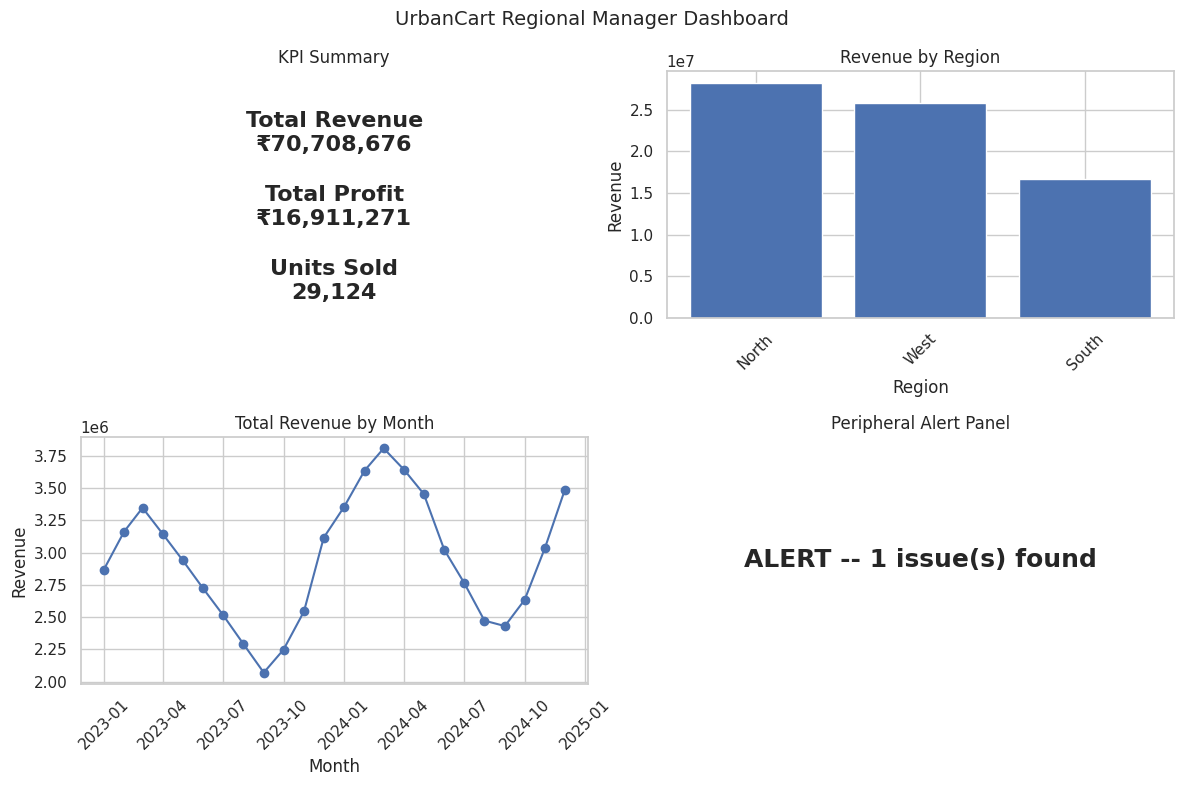

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# --- Panel 1: KPI summary (top-left) ---

total_revenue = sales_df["revenue"].sum()
total_profit = sales_df["profit"].sum()
total_units = sales_df["units_sold"].sum()

axes[0, 0].axis("off")

axes[0, 0].text(
    0.5, 0.75,
    f"Total Revenue\n₹{total_revenue:,.0f}",
    ha="center",
    va="center",
    fontsize=16,
    fontweight="bold"
)

axes[0, 0].text(
    0.5, 0.45,
    f"Total Profit\n₹{total_profit:,.0f}",
    ha="center",
    va="center",
    fontsize=16,
    fontweight="bold"
)

axes[0, 0].text(
    0.5, 0.15,
    f"Units Sold\n{total_units:,.0f}",
    ha="center",
    va="center",
    fontsize=16,
    fontweight="bold"
)

axes[0, 0].set_title("KPI Summary")


# --- Panel 2: revenue by region (top-right) ---

region_revenue = (
    sales_df.groupby("region")["revenue"]
    .sum()
    .sort_values(ascending=False)
)

axes[0, 1].bar(
    region_revenue.index,
    region_revenue.values
)

axes[0, 1].set_title("Revenue by Region")
axes[0, 1].set_xlabel("Region")
axes[0, 1].set_ylabel("Revenue")
axes[0, 1].tick_params(axis="x", rotation=45)


# --- Panel 3: total revenue by month, all stores (bottom-left) ---

monthly_revenue = (
    sales_df.groupby("month")["revenue"]
    .sum()
)

axes[1, 0].plot(
    monthly_revenue.index,
    monthly_revenue.values,
    marker="o"
)

axes[1, 0].set_title("Total Revenue by Month")
axes[1, 0].set_xlabel("Month")
axes[1, 0].set_ylabel("Revenue")
axes[1, 0].tick_params(axis="x", rotation=45)


# --- Panel 4: peripheral alert panel (bottom-right) ---
# Detect any (store_id, product) pair with a month below
# 25% of its own median units_sold

monthly_units = (
    sales_df.groupby(["store_id", "product", "month"])["units_sold"]
    .sum()
    .reset_index()
)

pair_medians = (
    monthly_units.groupby(["store_id", "product"])["units_sold"]
    .median()
    .reset_index(name="median_units")
)

monthly_units = monthly_units.merge(
    pair_medians,
    on=["store_id", "product"]
)

alerts = monthly_units[
    monthly_units["units_sold"] < 0.25 * monthly_units["median_units"]
]

n_issues = len(alerts)

axes[1, 1].axis("off")

if n_issues > 0:
    axes[1, 1].text(
        0.5, 0.5,
        f"ALERT -- {n_issues} issue(s) found",
        ha="center",
        va="center",
        fontsize=18,
        fontweight="bold"
    )
else:
    axes[1, 1].text(
        0.5, 0.5,
        "OK",
        ha="center",
        va="center",
        fontsize=22,
        fontweight="bold"
    )

axes[1, 1].set_title("Peripheral Alert Panel")


fig.suptitle("UrbanCart Regional Manager Dashboard", fontsize=14)
plt.tight_layout()
plt.show()


## Reflection

Answer briefly, referring back to the three manager complaints from the scenario intro:

1. Which single technique from this activity do you think gives UrbanCart's managers the *biggest*
   time saving, and why?
2. Which technique was hardest to implement well, and what design trade-off (from the lecture) did you
   have to think about while building it?
3. If you had to add **one more** interaction technique from the lecture that this activity didn't
   cover (e.g. geometric fisheye, magic lens, network zooming, model-based planning), where in this
   retail scenario would it actually be useful, and why?

_Your answers here._
1. **Biggest time saving:**
   The **coordinated views and interactive filtering** technique gives the biggest time saving because managers can quickly filter and focus on the specific store, product, region, or time period they are interested in instead of manually checking multiple charts or tables.

2. **Hardest to implement:**
   The **peripheral alert panel and anomaly detection** was the hardest to implement because it required identifying unusual values relative to each store-product pair. The main design trade-off was **overview vs. detail**: showing too much information can create visual clutter, while showing too little can hide important problems. The dashboard therefore keeps the overview simple and highlights only important issues.

3. **One additional technique:**
   I would add a **geometric fisheye** interaction to the monthly sales trend. Managers could enlarge a selected month or region while keeping the surrounding months visible in context. This would help them investigate sudden sales changes without completely losing the overall trend.
